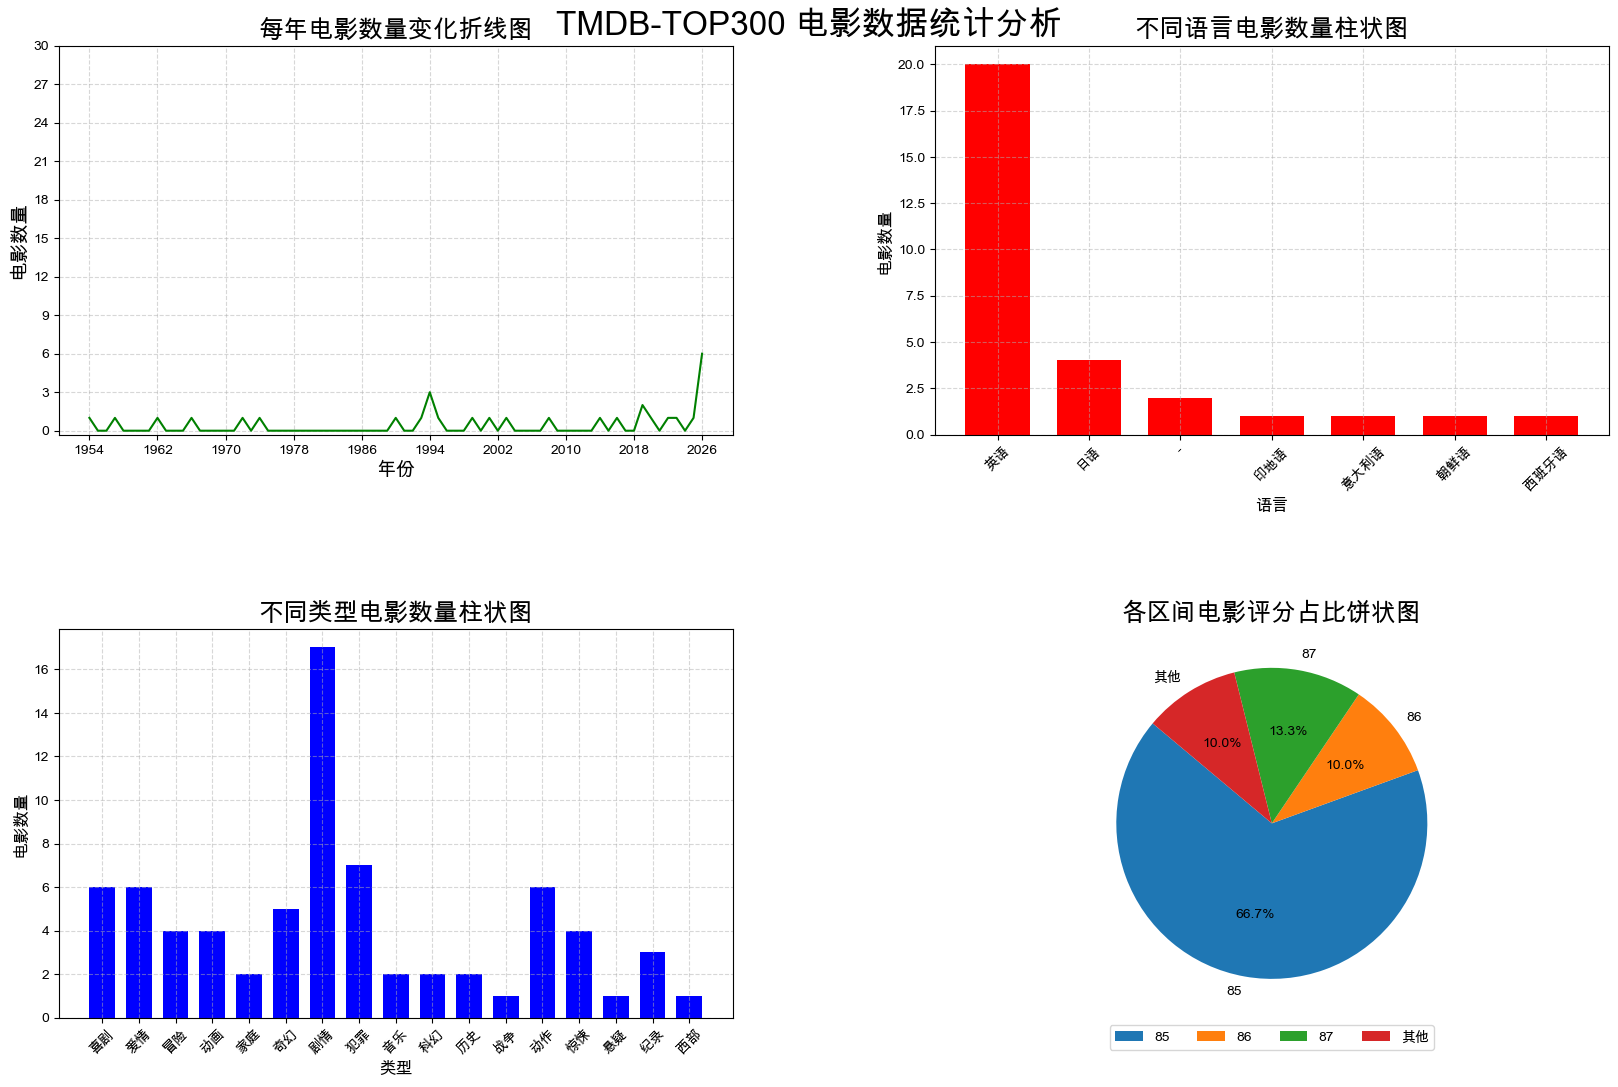

In [59]:
from pandas import Series

"""
TMDB-TOP300 电影数据统计分析

分析流程
准备工作：导入依赖库、配置运行时参数、创建子图完成基本布局、加载数据集

上映年份分析：统计 TOP300 影片中各年份上映电影数量变化，使用折线图可视化展示趋势
影片语言分析：统计并对比不同语言的电影数量，采用柱状图直观对比
电影类型分析：统计并对比不同题材类型的电影数量，使用柱状图呈现分布情况
评分分布分析：统计各区间电影评分占比情况，通过饼状图展示评分结构
"""
import pandas as pd
from matplotlib.axes import Axes
import matplotlib.pyplot as plt

# 展示中文
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'STHeiti']  # macOS 中文字体

# 创建子图
figure, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), dpi=100)

# 添加画布表标题
figure.suptitle('TMDB-TOP300 电影数据统计分析', fontsize=24, x=0.5, y=0.95)  # x: 水平位置, y: 垂直位置
# 设置子图间距
figure.subplots_adjust(hspace=0.5, wspace=0.3, top=0.92)  # hspace：行间距, wspace：列间距, top：画布上边距

# 获取子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 加载数据
# int64: 整型数字（不支持空值）
# Int64: 整型数字（支持空值）
# float64: 浮点型数字（支持空值）
data = pd.read_csv(
    'data/movie_list.csv',
    nrows=30,  # 读取前30行数据
    usecols=['电影名', '电影年份', '上映时间', '电影类型', '电影时长', '用户评分', '语言'],
    dtype={
        '电影年份': 'Int64'
    }
)

# 需求一：统计 TOP300 影片中各年份上映电影数量变化，使用折线图可视化展示趋势
# 1.1 缺失值、异常值处理
# data.isnull().sum() # 统计缺失值
data['电影年份'] = data['电影年份'].fillna(data['上映时间'].str[:4])

# 1.2 分组统计
year_count = data.groupby('电影年份')['电影年份'].count()

# 1.3 组装数据
# 组装x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()

"""
等价于：
x = []
for i in range(min_year, max_year + 1):
    x.append(i)
"""
x = [i for i in range(min_year, max_year + 1)]

# 组装y轴数据
"""
等价于：
y = []
for i in x:
    val = year_count.get(i, 0)  # 如果字典存在这个年份 → 返回对应的电影数量；如果字典没有这个年份（该年份没有上榜电影）→ 返回默认值 0
    y.append(int(val))
"""
y = [int(year_count.get(i, 0)) for i in x]
y

# 1.4 绘制折线图
axes1.plot(x, y, color="green")
axes1.set_title('每年电影数量变化折线图', fontsize=18)
axes1.set_xlabel('年份', fontsize=14)
axes1.set_ylabel('电影数量', fontsize=14)
axes1.set_xticks(x[::8])  # 设置x轴刻度, 0::8 表示从0开始，每隔8个单位取一个刻度
axes1.set_yticks([i for i in range(0, 31, 3)])  # 设置y轴刻度, 0::3 表示从0开始，到30为止，每隔3个单位取一个刻度
axes1.grid(linestyle='--', alpha=0.5)  # 添加网格

#------------------------------------------------------------------------------------------------------------------
# 需求二：统计并对比不同语言的电影数量，采用柱状图直观对比
"""
for lang, df in data.groupby('语言'):  # 输出时让数据对齐
    print("语言：", lang)
    print("-" * 20)

    # 输出具体该组内容
    print(df)

print("=" * 100)
"""

# 2.1 获取不同语言对应的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)

x_language = language_count.index.tolist()
y_language = language_count.values.tolist()

# 2.2 绘制柱状图
axes2.bar(x_language, y_language, color='red', width=0.7)
axes2.set_title('不同语言电影数量柱状图', fontsize=18)
axes2.set_xlabel('语言', fontsize=12)
axes2.set_ylabel('电影数量', fontsize=12)
axes2.grid(linestyle='--', alpha=0.5)
axes2.tick_params(axis='x', rotation=45)  # x轴刻度旋转45度

#------------------------------------------------------------------------------------------------------------------
# 需求三：统计并对比不同题材类型的电影数量，使用柱状图呈现分布情况
# 3.1 获取不同类型对应的电影数量
type_count = {}  # {'剧情':5, '犯罪':3}
for types in data['电影类型'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1

# 3.2 绘制柱状图
x_types = list(type_count.keys())
y_values = list(type_count.values())
axes3.bar(x_types, y_values, color='blue', width=0.7)
axes3.set_title('不同类型电影数量柱状图', fontsize=18)
axes3.set_xlabel('类型', fontsize=12)
axes3.set_ylabel('电影数量', fontsize=12)
axes3.grid(linestyle='--', alpha=0.5)
axes3.tick_params(axis='x', rotation=45)  # x轴刻度旋转45度

#------------------------------------------------------------------------------------------------------------------
# 需求四：统计各区间电影评分占比情况，通过饼状图展示评分结构
# 4.1 获取各区间对应的电影数量
score_count = data.groupby('用户评分')['用户评分'].count()

# 合并小数据（比例小于5%）
total = score_count.sum()
large_scores: Series = score_count.loc[score_count / total > 0.05]  # 大数据，比例 > 5%
small_scores: Series = score_count.loc[score_count / total <= 0.05]  # 小数据，比例 <= 5%

# 如果有小数据，则合并到“其他”类别中
"""
if small_scores.shape[0] > 0 代码拆解:

small_scores：一般是 pandas 的 DataFrame 或者 Series（筛选出来的一部分电影数据，比如高分电影子集）
.shape：shape 返回一个元组 (行数, 列数)   --->  例：(25, 4) → 25 行，4 列
.shape[0]   --->  取元组第 0 位，代表 数据有多少行 = 有多少条电影数据
> 0   --->  行数大于 0，说明存在符合条件的数据
"""
if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist()  # 评分列表
scores_values = large_scores.values.tolist()  # 数量列表

# 4.2 绘制饼状图
axes4.pie(scores_values, labels=scores, autopct='%1.1f%%',
          startangle=140, radius=1)  # autopct='%1.1f%%' 表示显示百分比，startangle=140 表示从140度开始绘制; radius=1 表示饼状图的半径为1
axes4.set_title('各区间电影评分占比饼状图', fontsize=18)
axes4.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))  # 0.5: 水平居中, -0.1: 垂直位置

# 5.保存图片
figure.savefig('data/movie_stats.png', dpi=100)

plt.show()  # 用于后续将文件转到python文件时，可显示图表